# Selecionando ativos utilizando KMeans e aplicando Markowitz

In [1]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta

from tqdm import tqdm
import random
from yahooquery import Ticker
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer # visualização e cálculo do número ideal de clusters
from sklearn.metrics import pairwise_distances_argmin_min # Calcular a distância entre os centróides e os pontos


import warnings
warnings.filterwarnings("ignore")

## 1- Obtendo os tickers da bolsa

- Inicialmente são apresentados três opções: IBOV, Nasdaq, S&P 500.
- Esolha uma e comente as restantes

### Pegando os Tickers da Bovespa

### Pegando os Tickers da Nasdaq

### Pegando os Tickers do S&P 500

In [2]:
# URL da Wikipedia com os componentes do S&P 500
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Lê a primeira tabela da página
tabela = pd.read_html(url)[0]

# Extrai a coluna de símbolos
tickers_sp500 = tabela['Symbol'].tolist()

# Corrige o formato dos tickers (por exemplo, BRK.B vira BRK-B, que é o formato usado no yfinance)
tickers_yf = [ticker.replace('.', '-') for ticker in tickers_sp500]

# Por motivos de poder computacional, vamos trabalhar com apenas n ativos
n_ativos = 60  # Defina o número de ativos que você deseja usar
tickers_yf = tickers_yf[:n_ativos]

## 2 - Baixando os Dados do Yahoo Finance

In [3]:
# Baixando os dados do Yahoo Finance

# datas de início e fim
start_date = '2023-01-01'
end_date = '2024-01-01'

# Convertendo as datas para o formato datetime
start_date = dt.datetime.strptime(start_date, '%Y-%m-%d')
end_date = dt.datetime.strptime(end_date, '%Y-%m-%d')

tickers_obj = Ticker(tickers_yf)
df= tickers_obj.history(start= start_date, end= end_date, interval='1d')['close']

# Visualizando os dados
df.head()

symbol  date      
MMM     2023-01-03    102.399666
        2023-01-04    104.640465
        2023-01-05    102.809364
        2023-01-06    105.953178
        2023-01-09    106.011703
Name: close, dtype: float64

## 3 - Arrumando os dados

In [4]:
# Resetando o indice para facilidar a manipulação
df = df.reset_index()

# Pivotando o dataframe para que as colunas virem os tickers
df = df.pivot(index='date', columns='symbol', values='close')

# Renomeando o indice para 'Data'
df.index.name = 'Data'

# Visualizando os dados
df.tail()

symbol,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,BAX,BDX,BKR,BRK-B,GOOG,GOOGL,LNT,MMM,MO,T
Data,,,,,,,,,,,,,,,,,,,,,
2023-12-22,139.570007,193.600006,154.940002,140.800003,109.029999,73.839996,354.450012,598.750000,197.100006,71.459999,...,38.380001,243.000000,34.119999,356.470001,142.720001,141.490005,50.939999,88.904678,40.360001,16.549999
2023-12-26,139.809998,193.050003,154.619995,138.720001,109.230003,73.510002,353.429993,598.260010,198.869995,72.389999,...,38.580002,243.300003,34.779999,356.829987,142.820007,141.520004,50.930000,90.392975,40.340000,16.570000
2023-12-27,139.820007,193.149994,154.880005,136.550003,109.790001,73.540001,353.820007,596.080017,199.350006,72.169998,...,38.660000,242.500000,34.490002,356.950012,141.440002,140.369995,50.840000,90.919731,40.180000,16.580000
2023-12-28,139.770004,193.580002,154.750000,137.000000,110.400002,74.059998,351.589996,595.520020,200.240005,72.269997,...,38.799999,243.029999,34.200001,357.570007,141.279999,140.229996,51.320000,91.714050,40.180000,16.740000
2023-12-29,139.029999,192.529999,154.970001,136.139999,110.070000,74.269997,350.910004,596.599976,198.559998,72.220001,...,38.660000,243.830002,34.180000,356.660004,140.929993,139.690002,51.299999,91.404678,40.340000,16.780001


In [5]:
# Excluindo os dados faltantes

# Tamanho original do dataframe
print(f'Tamanho Original do DataFrame : {df.shape}')
# Excluindo os dados faltantes
df.dropna(axis = 0, inplace=True)

# Tamanho do dataframe após a exclusão dos dados faltantes
print(f'Tamanho do DataFrame após a exclusão dos dados faltantes : {df.shape}')

Tamanho Original do DataFrame : (250, 60)
Tamanho do DataFrame após a exclusão dos dados faltantes : (250, 60)


## 4 - Calculando o Indice Sharpe

In [6]:
# Criando as variáveis para o cálculo do Índice Sharpe

# Retorno diário dos ativos
retornos_diarios = df.pct_change()

# Retorno anualizado dos ativos
retorno_anualizado = retornos_diarios.mean() * 252

# Variância anualizado dos ativos
var_anualizada = retornos_diarios.var() * 252

In [7]:
# Adicionando as colunas ao DataFrame
df2 = pd.DataFrame(df.columns.values, columns=['Symbols'])
df2['returns'] = retorno_anualizado.values
df2['variance'] = var_anualizada.values

In [8]:
# Visualizando o DataFrame
df2.head()

,Symbols,returns,variance
0,A,-0.041361,0.071993
1,AAPL,0.456737,0.039789
2,ABBV,-0.027666,0.039000
3,ABNB,0.567611,0.180653
4,ABT,0.024117,0.039615


In [9]:
# Calculando o Índice Sharpe

# Taxa livre de risco anualizada
rf = 0.11  # * indicado colocar o valor da taxa SELIC para ativos brasileiros

# Índice Sharpe 
indice_sharpe = (retorno_anualizado - rf)/ var_anualizada

# Adionando o Índice Sharpe ao DataFrame
df2['sharpe_ratio'] = indice_sharpe.values

# Excluindo possiveis valores faltantes
df2.dropna(axis=0, inplace=True)

In [10]:
# Vizualizando os maiores Índices Sharpe
df2.sort_values(by='sharpe_ratio', ascending=False).head(6)

,Symbols,returns,variance,sharpe_ratio
1,AAPL,0.456737,0.039789,8.714328
7,ADBE,0.629492,0.101411,5.122648
37,APH,0.280726,0.034209,4.990759
31,AMZN,0.632897,0.109076,4.793866
19,AKAM,0.364067,0.057193,4.442265
55,GOOGL,0.501408,0.092405,4.235786


## 6 - KMeans

Iremos utilizar o método não supervisionado KMeans, como um pré-processamento para reduzir a dimensinalidade(reduzir os números de ações) e criar uma diversificação mais robusta.

Em resumo iremos agrupar as ações em Grupos(Cluster) e então iremos selecionarmos o ativo que mais represente este grupo cuja é o ativo mais próximo do centro(centroíde).

Motivos pelo uso do Kmeans:

- Redução de dimensinalidade : Ao selecionarmos k varáiveis do todo, iremos trabalhar apenas com KxK na matrix de covariância
- Diversificação intuitiva/robusta : Ao otimizar os clusters, o modelo é forçado a diversificar entre diferentes tipos de comportamento de mercado

Cuidados
- A escolha de k(número de clusters) é crucial, um k muito baixo agrupo demais os ativos e um k alta não resolve o problema da dimensinalidade

Atenção
 Ao final serão apresentadas duas abordagens para a escolha do ativo 
- 1: Escolhendo os ativos mais próximos de cada centróide
- 2: Escolhendo os ativos com maiores indices sharpe de cada cluster 


## Elbow Method

In [11]:
# Escolhendo o número ideal de clusters para o nosso problema

# mínimo de clusters
min_clusters = 2
# máximo de clusters
max_clusters = 10

X = df2[['returns','variance' ,'sharpe_ratio']].values

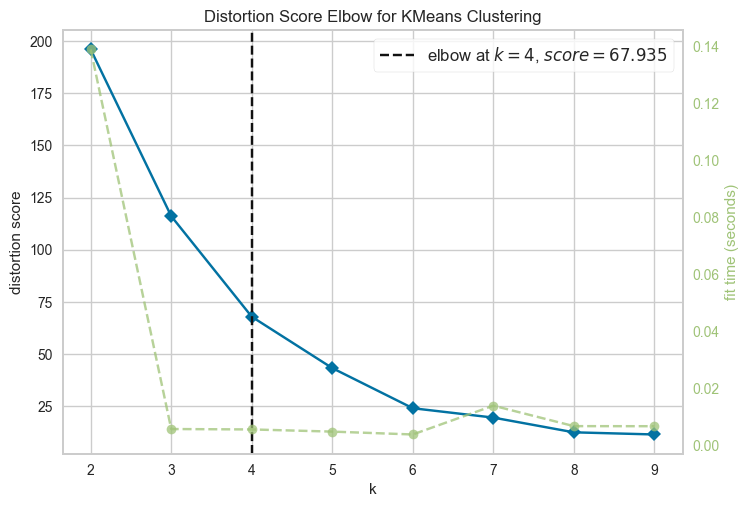

In [12]:
# Inicializando o modelo KMeans
kmodel = KMeans(random_state=42)


# Calculando o número ideal de clusters usando o método do cotovelo
visualizer = KElbowVisualizer(kmodel, k=(min_clusters,max_clusters))


visualizer.fit(X)        # treinando o medelo 
visualizer.show();     # Visualizando o gráfico do cotovelo

In [13]:
# Treinado o modelo KMeans com o número ideal de clusters
kmodel = KMeans(n_clusters= visualizer.elbow_value_).fit(X)
labels = kmodel.labels_ # array contendo o cluster de cada ativo

In [14]:
# Adiconando o cluter de cada ativo ao DataFrame
df2['cluster'] = labels
df2.head()

,Symbols,returns,variance,sharpe_ratio,cluster
0,A,-0.041361,0.071993,-2.102457,3
1,AAPL,0.456737,0.039789,8.714328,2
2,ABBV,-0.027666,0.039000,-3.529891,1
3,ABNB,0.567611,0.180653,2.533092,0
4,ABT,0.024117,0.039615,-2.167942,3


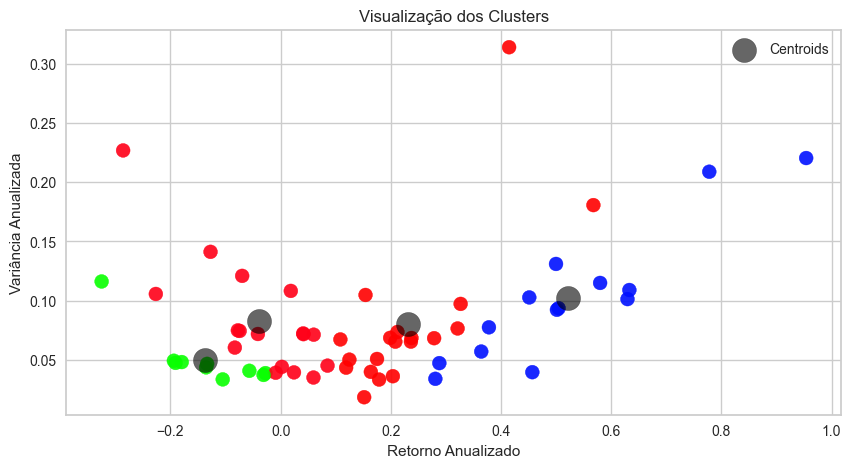

In [15]:
# Visualizando os Clusters

plt.figure(figsize=(10,5))
plt.scatter(X[:, 0], X[:, 1], c = labels, cmap='hsv', s=100, alpha=0.9)

# Visualizando os centros dos clusters
centers = kmodel.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c = 'black', s = 300, alpha=0.6, label='Centroids')
plt.title('Visualização dos Clusters')
plt.xlabel('Retorno Anualizado')
plt.ylabel('Variância Anualizada')
plt.legend()
plt.show();

In [16]:
# Pegando os ativos com maiores Índices Sharpe de cada cluster

representantes = df2.sort_values(by='sharpe_ratio', ascending=False).groupby('cluster').head(1)['Symbols'].tolist()
print(f'Ativos que irão representar a carteira: {representantes}')

Ativos que irão representar a carteira: ['AAPL', 'AIZ', 'AZO', 'ABBV']


In [17]:
# Criando um DataFrame com os ativos mais representativos de cada cluster
df_portifolio = df[representantes]

# excluindo os dados faltantes
df_portifolio.dropna(axis=0, inplace=True)

print(df_portifolio.shape)
df_portifolio.head()

(250, 4)


symbol,AAPL,AIZ,AZO,ABBV
Data,,,,
2023-01-03,125.070000,127.320000,2431.060059,162.380005
2023-01-04,126.360001,129.089996,2445.459961,163.690002
2023-01-05,125.019997,126.160004,2416.570068,163.490005
2023-01-06,129.619995,128.589996,2486.639893,166.550003
2023-01-09,130.149994,125.110001,2441.750000,161.660004


## 7 - Criando o Portifólio de Markowitz utilizando os ativos posteriormente escolhidos

In [18]:
# retornos 
returns_portifolio = df_portifolio.pct_change()

# retorno anualizado do portifólio
mean_returns_portifolio = returns_portifolio.mean() * 252

# variança anualizada do portifólio
var_portifolio = returns_portifolio.var() * 252

# covariancia do portifólio
cov_matrix_portifolio = returns_portifolio.apply(lambda x: np.log(1+x)).cov()

In [19]:
# Criando uma novo dataframe para armazenar os resultados
df_stocks = pd.DataFrame(df_portifolio.columns.values, columns=['Symbols'])

# Atribuindo os valores
df_stocks['returns'] = mean_returns_portifolio.values
df_stocks['variance'] = var_portifolio.values

In [20]:
# Visualizando o portifólio
# Visualizando os retornos e variância dos ativos do portifólio 
df_stocks.head()

,Symbols,returns,variance
0,AAPL,0.456737,0.039789
1,AIZ,0.321146,0.076645
2,AZO,0.085044,0.045309
3,ABBV,-0.027666,0.039000


In [21]:
# Array para armazenar os retornos do portifólio
retornos_portifolio = []

# Array para armazenar a volatilidade do portifólio
volatilidade_portifolio = []

# Array para armazenar o os pesos do portifólio
weights_portifolio = []

In [22]:
# numero de ativos no portifólio
n_assets = len(representantes)

# número de simulações de pesos para o portifólio
n_simulacoes = 30000

# peso mínimo para cada ativo
min_weight = 0.05

# peso máximo para cada ativo
max_weight = 0.95

# Armazenamento dos resultados
results = {
    'returns': [],
    'vol': [],
    'sharpe': [],
    'weight': []
}

In [23]:
# Simulação de pesos para o portifólio
for _ in range(n_simulacoes):
    # Gerando pesos aleatórios para os ativos
    weights = np.random.uniform(min_weight, max_weight, n_assets)
    # Normalizando os pesos para que a soma seja igual a 1
    weights = weights / np.sum(weights) 
    
    # Garantindo que os pesos estejam dentro do intervalo [min_weight, max_weight]
    if (weights >= min_weight).all() and (weights <= max_weight).all():
       retorno = np.dot(weights, mean_returns_portifolio)
       volatilidade = np.sqrt(np.dot(weights.T, np.dot(cov_matrix_portifolio, weights)))
       sharpe = retorno / volatilidade if volatilidade != 0 else 0
       
       results['returns'].append(retorno)
       results['vol'].append(volatilidade)
       results['sharpe'].append(sharpe)
       results['weight'].append(weights)
       

# Convertendo os resultados para um DataFrame
portifolio = pd.DataFrame(results)

In [24]:
# Pegando os pesos dos ativos do portifólio e convertendo para um DataFrame
# Cada coluna representa um ativo do portifólio e cada linha representa uma simulação de pesos
col_w = pd.DataFrame(portifolio['weight'].tolist(), columns=df_portifolio.columns)

# Adiconando os pesos ao DataFrame do portifólio
portifolio = pd.concat([portifolio, col_w], axis=1)

# Excluindo a coluna 'weight' que contém os pesos em formato de lista
portifolio.drop(columns=['weight'], inplace=True)

# visualizando o DataFrame do portifólio
print(portifolio.shape)
portifolio.head()

(26010, 7)


,returns,vol,sharpe,AAPL,AIZ,AZO,ABBV
0,0.186533,0.008536,21.853659,0.206446,0.213176,0.353456,0.226921
1,0.147872,0.010513,14.065857,0.101543,0.140036,0.687645,0.070776
2,0.130340,0.008755,14.886680,0.101868,0.206176,0.326007,0.365950
3,0.135686,0.008549,15.871659,0.136853,0.179002,0.307178,0.376967
4,0.145920,0.008975,16.257686,0.097039,0.287414,0.233577,0.381971


## 8 -  Fronteira eficiente

## Analisando os n portifólios criados 

In [25]:
# Pegando com os melhores resultados

id_best_sharpe = portifolio['sharpe'].idxmax()  # Índice do portifólio com o maior Índice Sharpe
id_min_vol = portifolio['vol'].idxmin()  # Índice do portifólio com a menor volatilidade


# Pegando os recpectivos dos portifólios
best_sharpe_port = portifolio.iloc[id_best_sharpe]
min_vol_port = portifolio.iloc[id_min_vol]

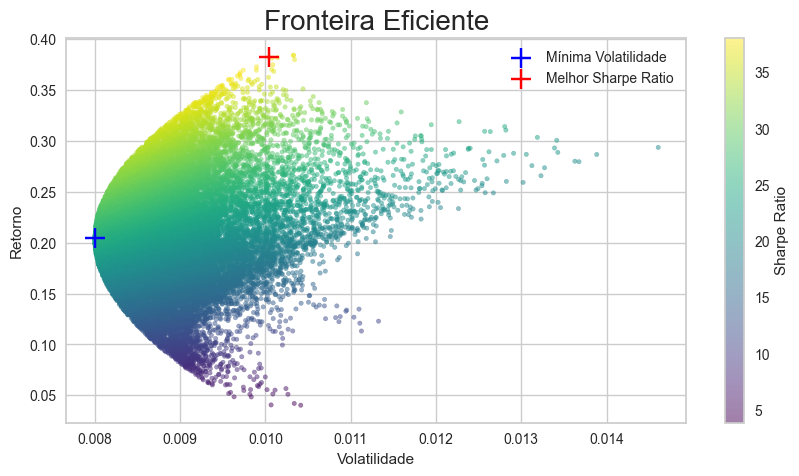

In [26]:
# Fronteira eficiente

plt.figure(figsize=(10,5))

scatter = plt.scatter(portifolio['vol'], portifolio['returns'], c= portifolio['sharpe'], cmap='viridis', s=10, alpha=0.5)
plt.xlabel('Volatilidade')
plt.ylabel('Retorno')
plt.colorbar(scatter, label = 'Sharpe Ratio')
plt.title('Fronteira Eficiente', fontsize=20)
# Plot dos portifólios com os melhores resultados
plt.scatter(min_vol_port['vol'], min_vol_port['returns'], color='blue',marker = '+', s=200, label='Mínima Volatilidade')
plt.scatter(best_sharpe_port['vol'], best_sharpe_port['returns'], color='red', marker = '+', s=200, label='Melhor Sharpe Ratio')
plt.grid(True)
plt.legend()
plt.show();

# 9 - Analisando os retornos dos Portífolio

Iremos analisar como cada portifólio performaria ao ano seguinte de seu cálculo

In [27]:
# Baixando os dados dos ativos do portifólio


# Para a validaão do portifólio, vamos baixar os dados referentes ao ano seguinte da criação do portifólio
# datas de início e fim
start_date_port = start_date + relativedelta(years= 1)
end_date_port = end_date + relativedelta(years= 1)


# tickers pertencentes ao portifólio
tickers = representantes
tickers_obj = Ticker(tickers)

df_port= tickers_obj.history(start= start_date_port, end= end_date_port, interval='1d')['close']

# Visualizando os dados
df_port.head()

symbol  date      
AAPL    2024-01-02    185.639999
        2024-01-03    184.250000
        2024-01-04    181.910004
        2024-01-05    181.179993
        2024-01-08    185.559998
Name: close, dtype: float64

In [28]:
# Arrumando o formato do dataframe

# Resetando o indice para facilidar a manipulação
df_port = df_port.reset_index()

# Pivotando o dataframe para que as colunas virem os tickers
df_port = df_port.pivot(index='date', columns='symbol', values='close')

# Renomeando o indice para 'Data'
df_port.index.name = 'Data'


# Retornos individuais de cada ativo
portifolio_returns = df_port.pct_change()*100

# Visualizando os dados
df_port.tail()

symbol,AAPL,ABBV,AIZ,AZO
Data,,,,
2024-12-24,258.200012,180.000000,215.429993,3283.479980
2024-12-26,259.019989,179.199997,217.190002,3241.250000
2024-12-27,255.589996,178.009995,215.050003,3241.620117
2024-12-30,252.199997,176.199997,212.270004,3185.709961
2024-12-31,250.419998,177.699997,213.220001,3202.000000


In [29]:
# Cálculo dos retornos do Portifólio
# Poritfólio com o melhor Índice Sharpe

# Filtra os retornos apenas para os ativos do portfólio
retornos_filtrados = portifolio_returns[representantes]

# Multiplica cada coluna (ativo) pelo seu peso
retornos_ponderados = retornos_filtrados * best_sharpe_port[representantes].iloc[0]

# Soma os retornos ponderados de cada dia (soma por linha)
retorno_portifolio = retornos_ponderados.sum(axis=1)

# Retorno acumulado
retorno_acumulado = retorno_portifolio.cumsum()

# Adiconando o retorno acumulado ao DataFrame
df_port['best_sharpe_ret_acc'] = retorno_acumulado.values

In [30]:
# Cálculo dos retornos do Portifólio
# Poritfólio com o menor volatilidade


# Multiplica cada coluna (ativo) pelo seu peso
retornos_ponderados = retornos_filtrados * min_vol_port[representantes].iloc[0]

# Soma os retornos ponderados de cada dia (soma por linha)
retorno_portifolio = retornos_ponderados.sum(axis=1)

# Retorno acumulado
retorno_acumulado = retorno_portifolio.cumsum()

# Adiconando o retorno acumulado ao DataFrame
df_port['min_vol_ret_acc'] = retorno_acumulado.values

In [31]:
# Cálculo dos Retornos de cada ativo do portifólio

retorno_acumulado_ativos = retornos_filtrados.cumsum(axis= 0)

# Pegando apenas a última linha, pois ela representa o retorno acumulado total
retorno_acumulado_ativos = retorno_acumulado_ativos.iloc[-1]

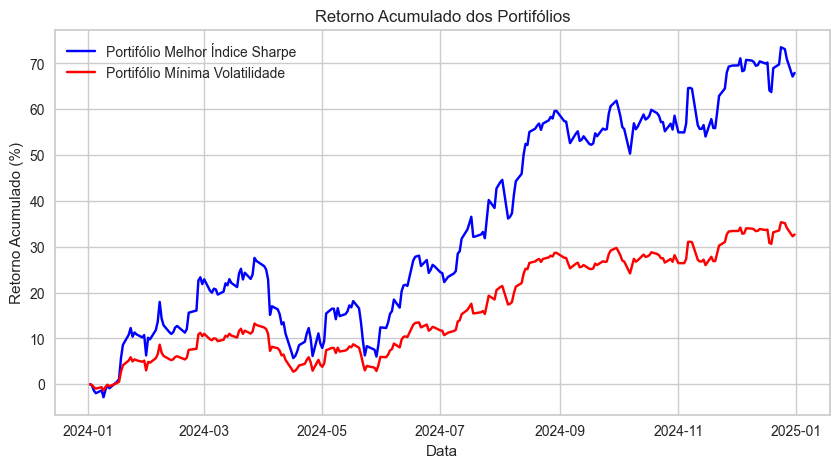

In [32]:
# Gráfico dos retornos acumulados dos portifólios

plt.figure(figsize=(10,5))

plt.plot(df_port.index, df_port['best_sharpe_ret_acc'], label='Portifólio Melhor Índice Sharpe', color='blue')
plt.plot(df_port.index, df_port['min_vol_ret_acc'], label='Portifólio Mínima Volatilidade', color='red')
plt.xlabel('Data')
plt.ylabel('Retorno Acumulado (%)')
plt.title('Retorno Acumulado dos Portifólios')
plt.legend()
plt.grid(True)
plt.show();

# 10 - **Quantas vezes Markowitz bate o becnmark**

- Serão analisados apenas os portifólios que satisfazem os critérios de pesos

In [33]:
# Armazemento dos resultados
benchmark = {
    'returns': [],
    'weight': [],
}


# Calculando os retornos dos ativos e armazenando em um vetor
weights_benchmark = retornos_filtrados.cumsum(axis=0)
weights_benchmark = weights_benchmark.iloc[-1].to_numpy()

In [34]:
# Calculando os retornos para cada portifílio criado 

for i in range(len(portifolio)):
    
    # Calculando o retorno do portifólio
    retorno = np.dot(portifolio[representantes].iloc[i], weights_benchmark)
    
    # Armazenando os resultados
    benchmark['returns'].append(retorno)
    benchmark['weight'].append(portifolio[representantes].iloc[i].to_numpy())
    

# Armazenando os resultados em um DataFrame
df_benchmark = pd.DataFrame(benchmark)

In [35]:
# Retorno dos ativos no período de validação
print('Retorno dos ativos no período de validação:')
display(retorno_acumulado_ativos)

Retorno dos ativos no período de validação:


symbol
AAPL    32.431245
AIZ     24.604803
AZO     24.197689
ABBV    13.505252
Name: 2024-12-31, dtype: float64

In [36]:
# Resultados dos portifólios criados 

# Maior retorno de um portifólio
print(f'Maior retorno de um portifólio: {df_benchmark["returns"].max():.2f}%')
print(f'Pesos do portifólio com maior retorno: {df_benchmark["weight"].iloc[df_benchmark["returns"].idxmax()]}')
print('-'*100)
# Menor retorno de um portifólio
print(f'Menor retorno de um portifólio: {df_benchmark["returns"].min():.2f}%')
print(f'Pesos do portifólio com menor retorno: {df_benchmark["weight"].iloc[df_benchmark["returns"].idxmin()]}')

Maior retorno de um portifólio: 29.95%
Pesos do portifólio com maior retorno: [0.76893632 0.08335882 0.0905585  0.05714636]
----------------------------------------------------------------------------------------------------
Menor retorno de um portifólio: 16.44%
Pesos do portifólio com menor retorno: [0.07049384 0.07267829 0.07442127 0.78240661]


In [37]:
# Verificando quantos portifólios bareram o benchmark

# Redefinindo o benchmark - podemos reutilizar o definindo anteriormente
benchmark_target = 5  # %

# Contador de portifólios que bateram o benchmark
beat_benchmark = np.sum(df_benchmark['returns'] > benchmark_target) / portifolio.shape[0]

print(f'Porcentagem de portifólios que bateram o benchmark: {beat_benchmark*100:.2f}%')

Porcentagem de portifólios que bateram o benchmark: 100.00%
